In [1]:
import mujoco
import numpy as np

# 定义不同的 solref 参数
solref_parameters = [
    "-2e3 0",  # 原始参数
    "-2e5 0",   # 中等刚度
    # "-2e6 0",   # 中等刚度
    "-3e6 0",   # 中等刚度
    "-2e8 0"    # 较低刚度
]

# 存储所有仿真结果
all_results = []

# 运行三次不同参数的仿真
for param_idx, solref in enumerate(solref_parameters):
  print(f"运行仿真 {param_idx+1}, solref={solref}")
    
  # MuJoCo模型XML字符串，使用当前参数
  MUJOCO_MODEL_XML = f"""
  <mujoco>
    <option timestep="0.001"/>

    <default>
      <geom solref="{solref}"/>
    </default>

    <worldbody>
      <camera name="fixed" pos="0 -15 5" xyaxes="1 0 0 0 0.7 1" mode="fixed"/>
      <!-- 地面 -->
      <geom name="ground" type="plane" size="10 10 1" pos="0 0 0" rgba="0.8 0.9 0.8 1"/>

      <!-- 方块 -->
      <body name="ball" pos="0 0 4.5">
        <freejoint/>
        <geom name="box_geom" type="box" size="0.5 0.5 0.5" rgba="0.9 0.2 0.2 1" mass="1"/>
      </body>
    </worldbody>

    <!-- 重力设置 -->
    <option gravity="0 0 -9.81"/>
  </mujoco>
  """

  # 创建模型和仿真环境
  model = mujoco.MjModel.from_xml_string(MUJOCO_MODEL_XML)
  data = mujoco.MjData(model)

  # 设置仿真时长
  simulation_time = 4.0  # 仿真时间（秒）
  num_steps = int(simulation_time / model.opt.timestep)

  # 存储时间和高度数据
  time_points = np.zeros(num_steps)
  height_points = np.zeros(num_steps)
  velocity_points = np.zeros(num_steps)

  # 运行仿真
  for i in range(num_steps):
      # 执行仿真步骤
      mujoco.mj_step(model, data)
      
      # 记录时间、高度和速度
      time_points[i] = data.time
      height_points[i] = data.qpos[2] - 0.5  # z坐标
      velocity_points[i] = data.qvel[2]  # z方向速度

  # 保存结果
  result = {
      'time': time_points,
      'height': height_points,
      'velocity': velocity_points,
      'solref': solref
  }
  all_results.append(result)
  
  print(f"仿真 {param_idx+1} 完成")


运行仿真 1, solref=-2e3 0
仿真 1 完成
运行仿真 2, solref=-2e5 0
仿真 2 完成
运行仿真 3, solref=-3e6 0
仿真 3 完成
运行仿真 4, solref=-2e8 0
仿真 4 完成


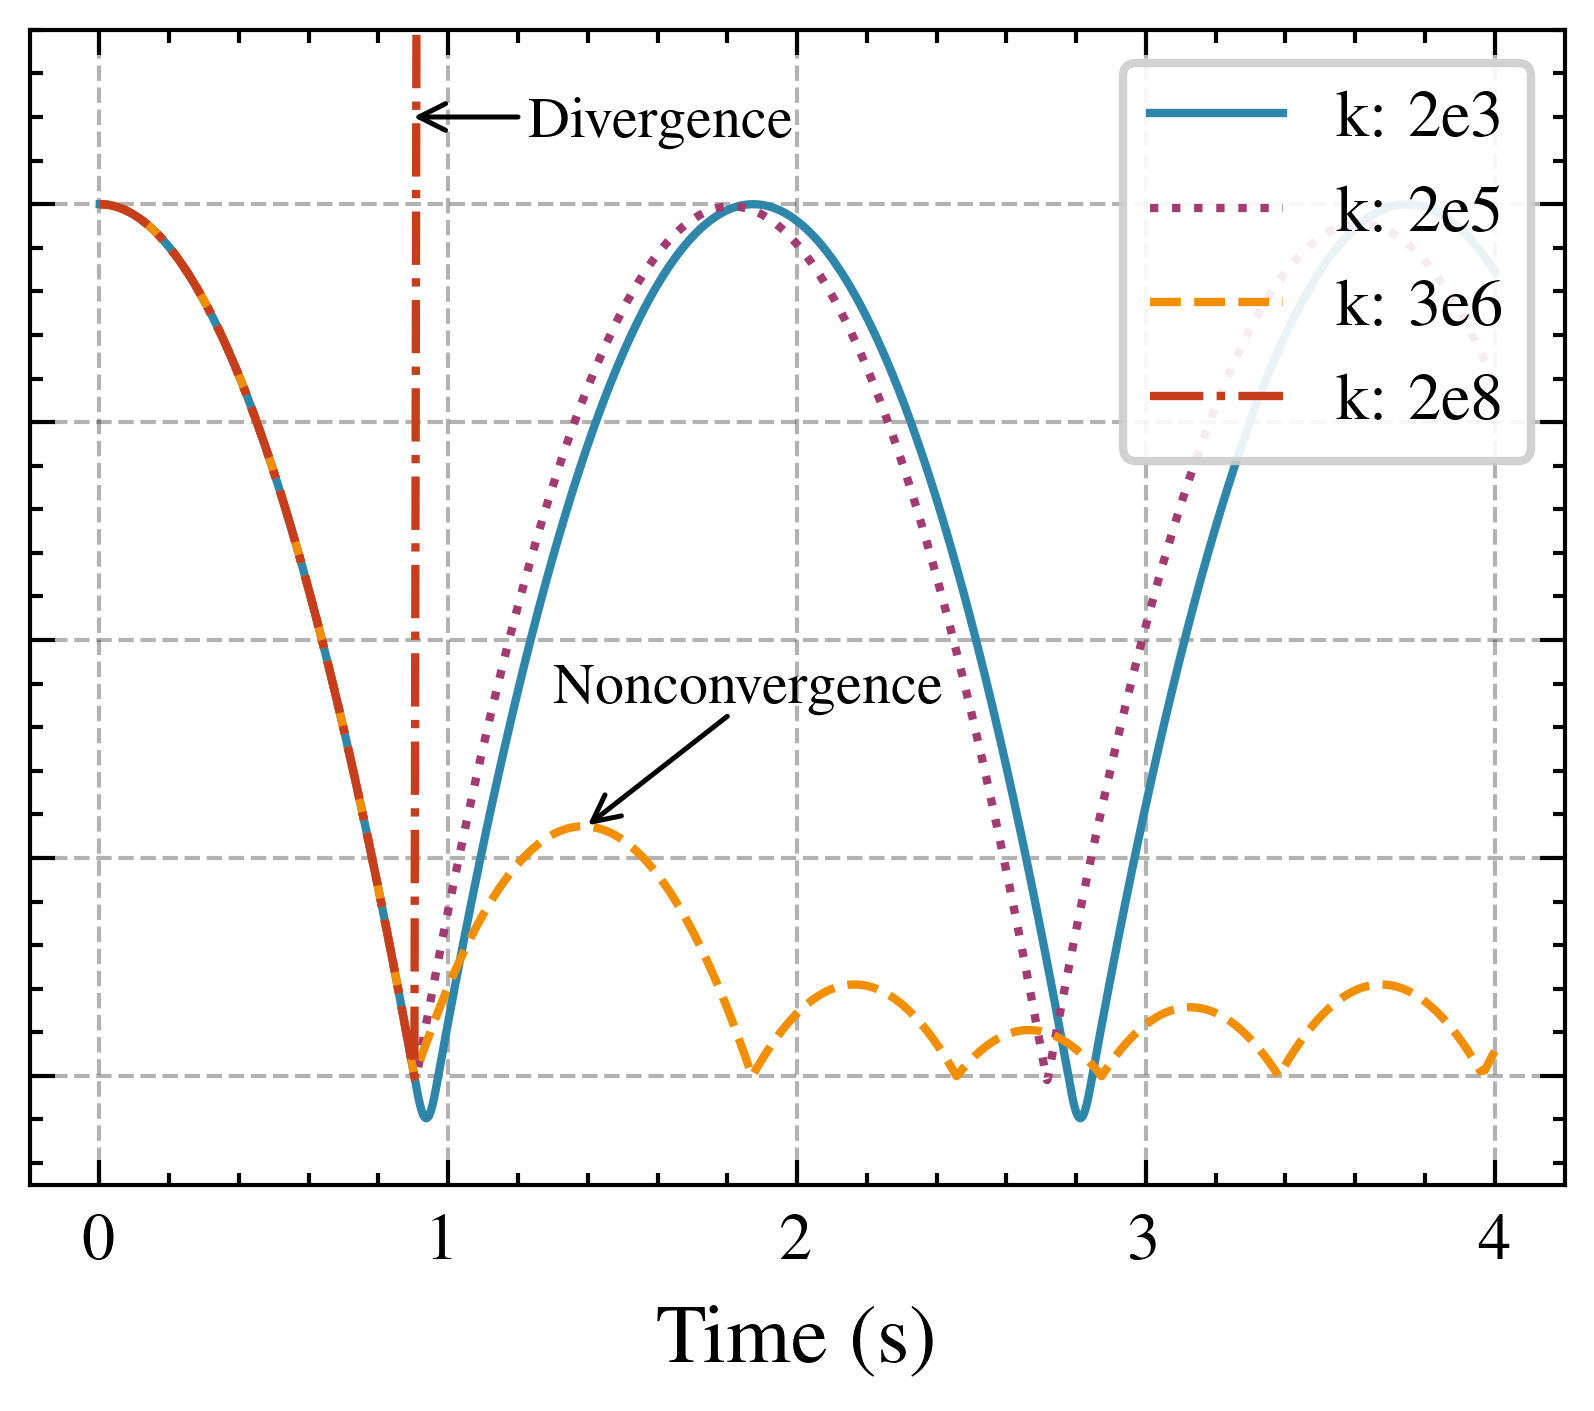

In [11]:
import matplotlib.pyplot as plt
import scienceplots  # 需要安装：pip install SciencePlots

# 指定支持扩展字符的字体
plt.rcParams['font.sans-serif'] = 'Microsoft YaHei'  # 或 'Source Han Sans', 'BabelStone Han'
# 使用科学论文风格绘制结果
with plt.style.context(['science', 'ieee', 'grid']):
    # 专业配色
    # linestyles = ["-", ":", "--"]
    linestyles = ["-", ":", "--", "-."]
    scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
    ]
    
    for i, result in enumerate(all_results[:]):
        time = result['time']
        height = result['height']
        solref = result['solref']
        # mask = height <= 5.0
        # filtered_time = time[mask]
        # filtered_height = height[mask]
        # 提取solref数值用于图例
        solref_value = solref.split()[0]
        
        # 绘制高度曲线
        plt.plot(time, height, linewidth=1, 
                label=f"k: {solref_value[1:]}", 
                color=scientific_colors[i], linestyle=linestyles[i % 4])
        linewidth = 0.6
        fontsize = 7
        if i == 3:
            # 选择连接点（椭圆上的点）
            connector_x = 0.9
            connector_y = 4.4

            # 文本位置
            text_x = connector_x + 0.3
            text_y = connector_y

            # 绘制连接线
            plt.annotate(
                '', 
                xy=(connector_x, connector_y), 
                xytext=(text_x, text_y),
                arrowprops=dict(
                    arrowstyle='->',
                    color="black",
                    lw=linewidth,
                    shrinkA=0,
                    shrinkB=0
                )
            )

            # 添加解释文本
            plt.text(
                text_x + 0.03, text_y - 0.03, 
                'Divergence',
                fontsize=fontsize,
                # bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7),
                verticalalignment='center',
                horizontalalignment='left'
            )
        if i == 2:
            # 选择连接点（椭圆上的点）
            connector_x = 1.4
            connector_y = 1.15

            # 文本位置
            text_x = connector_x + 0.4
            text_y = connector_y + 0.5

            # 绘制连接线
            plt.annotate(
                '', 
                xy=(connector_x, connector_y), 
                xytext=(text_x, text_y),
                arrowprops=dict(
                    arrowstyle='->',
                    color="black",
                    lw=linewidth,
                    shrinkA=0,
                    shrinkB=0
                )
            )

            # 添加解释文本
            plt.text(
                text_x + 0.06, text_y, 
                'Nonconvergence',
                fontsize=fontsize,
                # bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7),
                verticalalignment='bottom',
                horizontalalignment='center'
            )
    
    plt.legend(framealpha=0.9, loc="upper right")
    # plt.ylabel(r'Height (m)')
    plt.gca().set_yticklabels([])
    plt.xlabel(r'Time (s)', fontsize=10)
    plt.ylim(top=4.8, bottom=-0.5)
    plt.grid(True, alpha=0.3)
    # plt.title('Bouncing ball by MuJoCo')
    # plt.tight_layout()
    # plt.savefig("sphere_free_fall_height_mujoco.pdf", format="pdf")
    plt.savefig("D:/papers/sire_contact_model/res/box_free_fall_height_mujoco.pdf", format="pdf", dpi=600, bbox_inches='tight')
    plt.show()
#     i = i + 1
# #     if i >= len(all_results):
# #         exit()
#     result = all_results[i]
#     time = result['time']
#     height = result['height']
#     solref = result['solref']
    
#     # 提取solref数值用于图例
#     solref_value = solref.split()[0]
    
#     # 绘制高度曲线
#     plt.semilogy(time, height, linewidth=1, 
#             label=f"k: {solref_value[1:]}", 
#             color=colors[i])
#     plt.legend(loc="best", fontsize=10)
#     plt.ylabel(r'Height (m)')
#     plt.xlabel(r'Time (s)')
#     plt.grid(True, linestyle='--', alpha=0.7)
#     plt.title('Free Fall with Different Contact Stiffness')
#     plt.tight_layout()
#     # plt.savefig("sphere_free_fall_height_comparison.pdf", format="pdf")
#     plt.show()

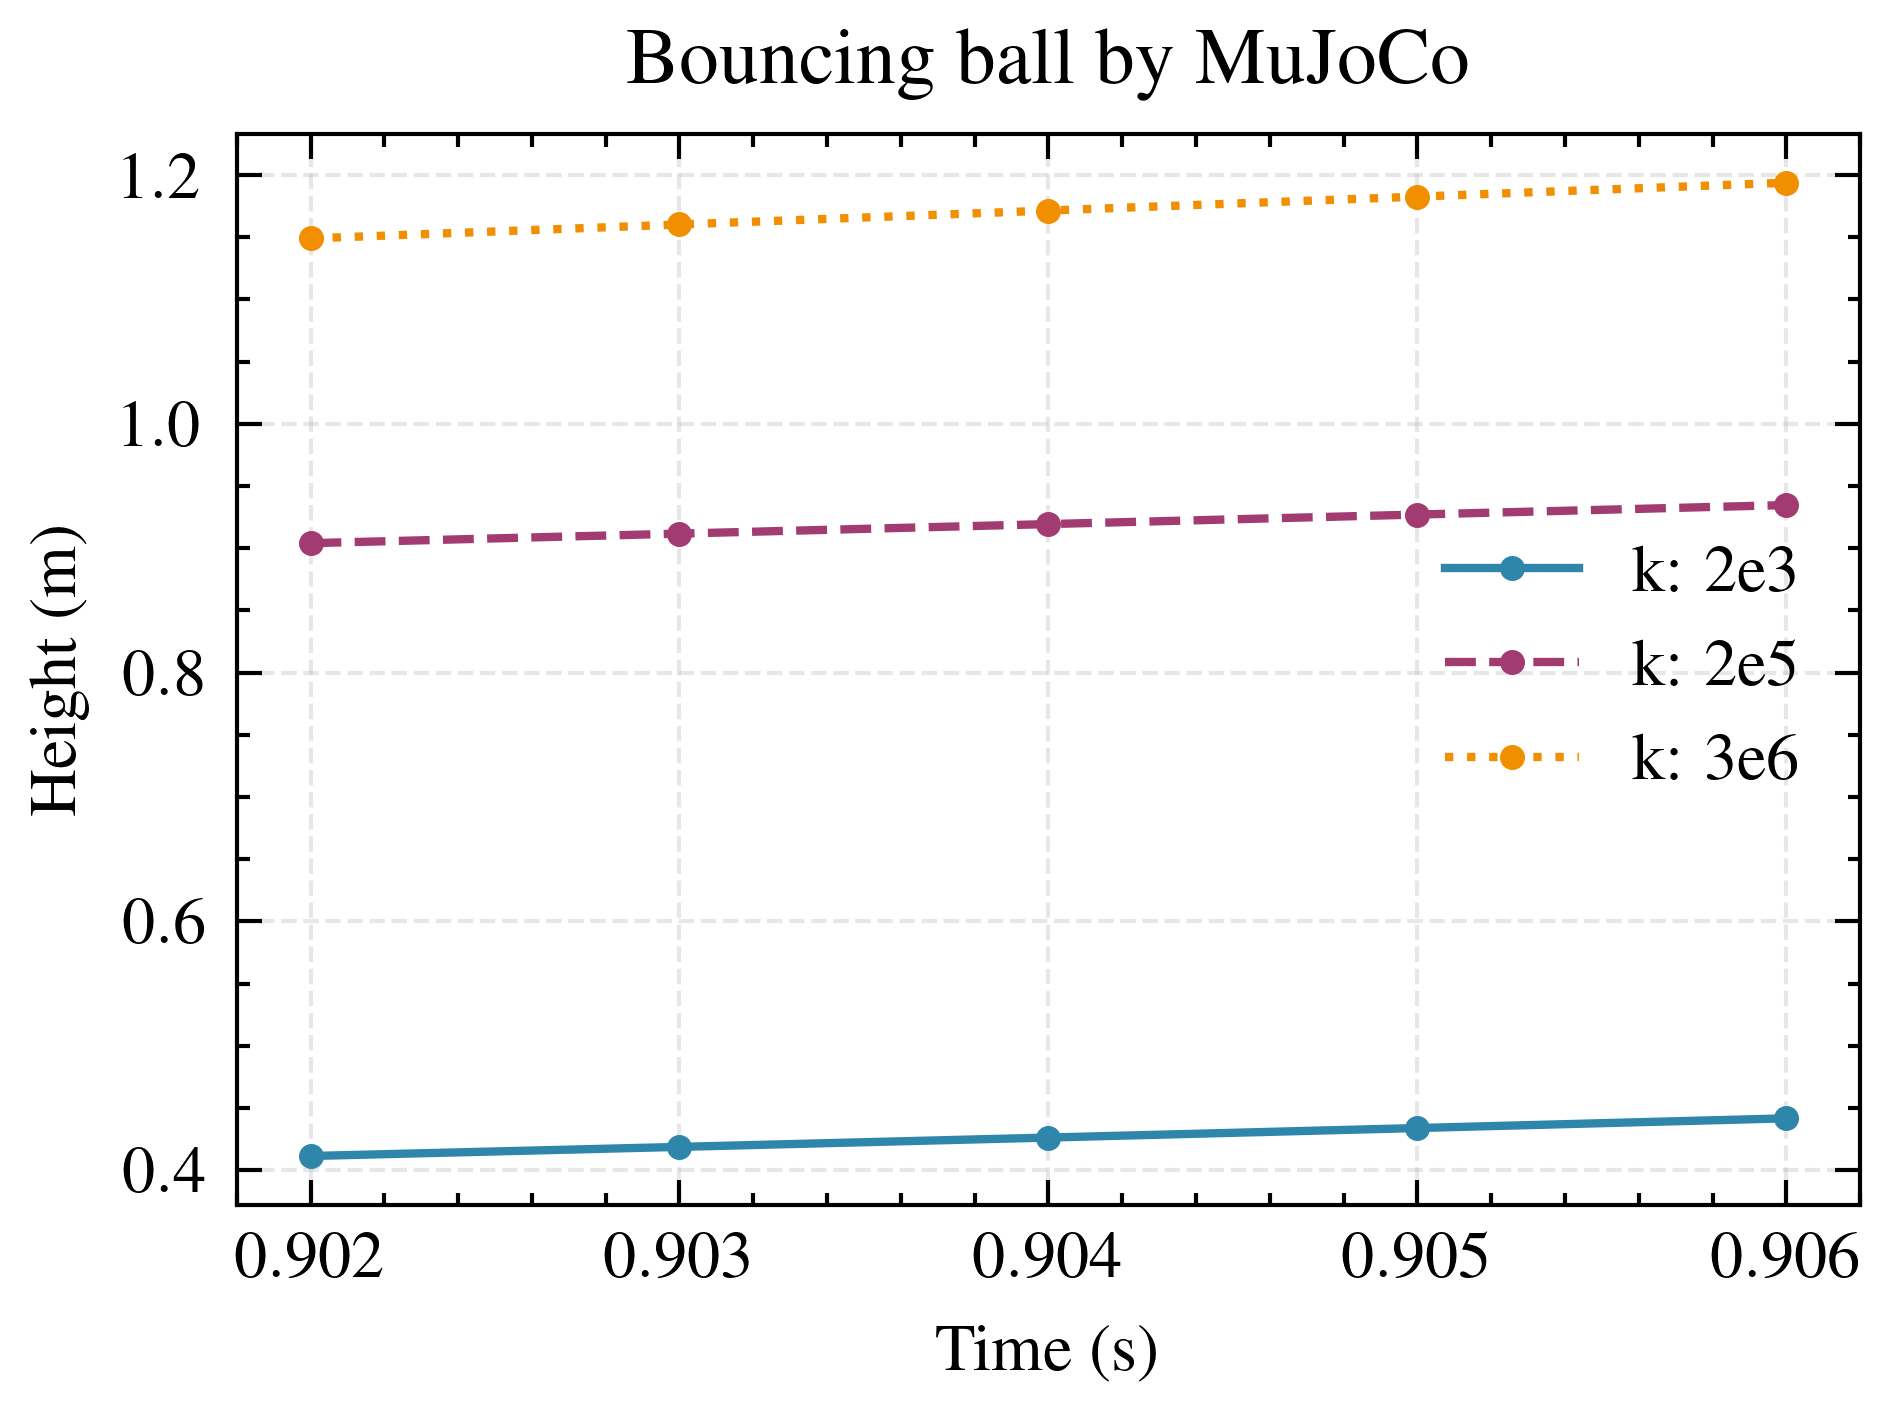

In [21]:
# 使用科学论文风格绘制结果
with plt.style.context(['science', 'ieee']):
    # 专业配色
    # linestyles = ["-", ":", "--"]
    linestyles = ["-","--", ":"]
    scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
    ]
    
    for i, result in enumerate(all_results[:-1]):
        time = result['time']
        height = result['height']
        solref = result['solref']
        mask1 = time >= 0.902
        mask2 = time <= 0.906 + 1e-6
        combined_mask = mask1 & mask2 
        filtered_time = time[combined_mask]
        filtered_height = height[combined_mask]
        # 提取solref数值用于图例
        solref_value = solref.split()[0]
        # 绘制高度曲线
        plt.plot(filtered_time, filtered_height, 
                 marker='o', markersize=2,
                label=f"k: {solref_value[1:]}", 
                color=scientific_colors[i])

    plt.ylabel(r'Height (m)')
    plt.xlabel(r'Time (s)')
    plt.legend()
    # plt.ylim(top=7, bottom=-0.3)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.title('Bouncing ball by MuJoCo')
    plt.tight_layout()
    # plt.savefig("sphere_free_fall_height_mujoco.pdf", format="pdf")
    # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_mujoco.pdf", format="pdf")
    plt.show()

## Performance Tests

### Duration 10s simulation profile without dissipation.

In [ ]:
import mujoco
import numpy as np
import time
# 定义不同的 solref 参数
solref_parameters = [
    "-2e3 0",  # 原始参数
    "-2e5 0",   # 中等刚度
    # "-2e6 0",   # 中等刚度
    "-3e6 0",   # 中等刚度
    "-2e8 0"    # 较低刚度
]

# 存储所有仿真结果
n = 40
timeCostResult = np.zeros([len(solref_parameters), n])
# 运行三次不同参数的仿真
for param_idx, solref in enumerate(solref_parameters):
    print(f"运行仿真 {param_idx+1}, solref={solref}")
    for j in range(n):
    # MuJoCo模型XML字符串，使用当前参数
      MUJOCO_MODEL_XML = f"""
  <mujoco>
    <option timestep="0.001"/>

    <default>
      <geom solref="{solref}"/>
    </default>

    <worldbody>
      <camera name="fixed" pos="0 -15 5" xyaxes="1 0 0 0 0.7 1" mode="fixed"/>
      <!-- 地面 -->
      <geom name="ground" type="plane" size="10 10 1" pos="0 0 0" rgba="0.8 0.9 0.8 1"/>

      <!-- 方块 -->
      <body name="ball" pos="0 0 4.5">
        <freejoint/>
        <geom name="box_geom" type="box" size="0.5 0.5 0.5" rgba="0.9 0.2 0.2 1" mass="1"/>
      </body>
    </worldbody>

    <!-- 重力设置 -->
    <option gravity="0 0 -9.81"/>
  </mujoco>
  """

      # 创建模型和仿真环境
      model = mujoco.MjModel.from_xml_string(MUJOCO_MODEL_XML)
      data = mujoco.MjData(model)

      # 设置仿真时长
      simulation_time = 10.0  # 仿真时间（秒）
      num_steps = int(simulation_time / model.opt.timestep)

      # 存储时间和高度数据
      time_points = np.zeros(num_steps)
      height_points = np.zeros(num_steps)
      velocity_points = np.zeros(num_steps)

      start = time.perf_counter()
      # 运行仿真
      for i in range(num_steps):
          # 执行仿真步骤
          mujoco.mj_step(model, data)
      end = time.perf_counter()
      elapsed = end - start
      timeCostResult[param_idx][j] = elapsed
    print(f"仿真 {param_idx+1} 完成")

np.savetxt(
    'mujoco_perf_measure_10s_zero_dissipation.csv',          # Filename
    timeCostResult.transpose(),  # Combine x and y into two columns
    delimiter=',',            # Use comma as delimiter
    comments=''               # Remove '#' from header
)

运行仿真 1, solref=-2e3 0
仿真 1 完成
运行仿真 2, solref=-2e5 0
仿真 2 完成
运行仿真 3, solref=-3e6 0
仿真 3 完成
运行仿真 4, solref=-2e8 0
仿真 4 完成


In [ ]:
# Read data from CSV using NumPy
data = np.genfromtxt('mujoco_perf_measure_10s_zero_dissipation.csv', delimiter=',')

print(np.sum(data, 0) / data.shape[0])


[0.02566822 0.02583706 0.02477975 0.02456941]


### Duration 10s simulation profile with high dissipation.

In [ ]:
import mujoco
import numpy as np
import time
# 定义不同的 solref 参数
solref_parameters = [
    "-2e3 -1e5",  # 原始参数
    "-2e5 -1e5",   # 中等刚度
    # "-2e6 0",   # 中等刚度
    "-3e6 -1e5",   # 中等刚度
    "-2e8 -1e5"    # 较低刚度
]

# 存储所有仿真结果
n = 40
timeCostResult = np.zeros([len(solref_parameters), n])
# 运行三次不同参数的仿真
for param_idx, solref in enumerate(solref_parameters):
    print(f"运行仿真 {param_idx+1}, solref={solref}")
    for j in range(n):
    # MuJoCo模型XML字符串，使用当前参数
      MUJOCO_MODEL_XML = f"""
  <mujoco>
    <option timestep="0.001"/>

    <default>
      <geom solref="{solref}"/>
    </default>

    <worldbody>
      <camera name="fixed" pos="0 -15 5" xyaxes="1 0 0 0 0.7 1" mode="fixed"/>
      <!-- 地面 -->
      <geom name="ground" type="plane" size="10 10 1" pos="0 0 0" rgba="0.8 0.9 0.8 1"/>

      <!-- 方块 -->
      <body name="ball" pos="0 0 4.5">
        <freejoint/>
        <geom name="box_geom" type="box" size="0.5 0.5 0.5" rgba="0.9 0.2 0.2 1" mass="1"/>
      </body>
    </worldbody>

    <!-- 重力设置 -->
    <option gravity="0 0 -9.81"/>
  </mujoco>
  """

      # 创建模型和仿真环境
      model = mujoco.MjModel.from_xml_string(MUJOCO_MODEL_XML)
      data = mujoco.MjData(model)

      # 设置仿真时长
      simulation_time = 10.0  # 仿真时间（秒）
      num_steps = int(simulation_time / model.opt.timestep)

      # 存储时间和高度数据
      time_points = np.zeros(num_steps)
      height_points = np.zeros(num_steps)
      velocity_points = np.zeros(num_steps)

      start = time.perf_counter()
      # 运行仿真
      for i in range(num_steps):
          # 执行仿真步骤
          mujoco.mj_step(model, data)
      end = time.perf_counter()
      elapsed = end - start
      timeCostResult[param_idx][j] = elapsed
    print(f"仿真 {param_idx+1} 完成")

np.savetxt(
    'mujoco_perf_measure_10s_high_dissipation.csv',          # Filename
    timeCostResult.transpose(),  # Combine x and y into two columns
    delimiter=',',            # Use comma as delimiter
    comments=''               # Remove '#' from header
)

运行仿真 1, solref=-2e3 -1e5
仿真 1 完成
运行仿真 2, solref=-2e5 -1e5
仿真 2 完成
运行仿真 3, solref=-3e6 -1e5
仿真 3 完成
运行仿真 4, solref=-2e8 -1e5
仿真 4 完成


In [4]:
# Read data from CSV using NumPy
data = np.genfromtxt('mujoco_perf_measure_10s_high_dissipation.csv', delimiter=',')

print(np.sum(data, 0) / data.shape[0])


[0.0248164  0.02337079 0.0249731  0.02499181]


### Contact profile

In [ ]:
import mujoco
import numpy as np
import time
# 定义不同的 solref 参数
solref_parameters = [
    "-2e3 0",  # 原始参数
    "-2e5 0",   # 中等刚度
    # "-2e6 0",   # 中等刚度
    "-3e6 0",   # 中等刚度
    "-2e8 0"    # 较低刚度
]

# 存储所有仿真结果
n = 1000
timeCostResult = np.zeros([len(solref_parameters), n])
# 运行三次不同参数的仿真
for param_idx, solref in enumerate(solref_parameters):
    print(f"运行仿真 {param_idx+1}, solref={solref}")
    for j in range(n):
    # MuJoCo模型XML字符串，使用当前参数
      MUJOCO_MODEL_XML = f"""
  <mujoco>
    <option timestep="0.001"/>

    <default>
      <geom solref="{solref}"/>
    </default>

    <worldbody>
      <camera name="fixed" pos="0 -15 5" xyaxes="1 0 0 0 0.7 1" mode="fixed"/>
      <!-- 地面 -->
      <geom name="ground" type="plane" size="10 10 1" pos="0 0 0" rgba="0.8 0.9 0.8 1"/>

      <!-- 方块 -->
      <body name="ball" pos="0 0 4.5">
        <freejoint/>
        <geom name="box_geom" type="box" size="0.5 0.5 0.5" rgba="0.9 0.2 0.2 1" mass="1"/>
      </body>
    </worldbody>

    <!-- 重力设置 -->
    <option gravity="0 0 -9.81"/>
  </mujoco>
  """

      # 创建模型和仿真环境
      model = mujoco.MjModel.from_xml_string(MUJOCO_MODEL_XML)
      data = mujoco.MjData(model)
      data.qpos[2] = 0.4912119999999864
      data.qvel[2] = -8.85920000000009
      

      # 设置仿真时长
      # simulation_time = 10.0  # 仿真时间（秒）
      # num_steps = int(simulation_time / model.opt.timestep)

      start = time.perf_counter()
      # 运行仿真
      # for i in range(num_steps):
          # 执行仿真步骤
      mujoco.mj_step(model, data)
      end = time.perf_counter()
      elapsed = end - start
      timeCostResult[param_idx][j] = elapsed
    print(f"仿真 {param_idx+1} 完成")
    
np.savetxt(
    'mujoco_perf_measure_contact.csv',          # Filename
    timeCostResult.transpose(),  # Combine x and y into two columns
    delimiter=',',            # Use comma as delimiter
    comments=''               # Remove '#' from header
)

运行仿真 1, solref=-2e3 0
仿真 1 完成
运行仿真 2, solref=-2e5 0
仿真 2 完成
运行仿真 3, solref=-3e6 0
仿真 3 完成
运行仿真 4, solref=-2e8 0
仿真 4 完成


In [6]:
data = np.genfromtxt('mujoco_perf_measure_contact.csv', delimiter=',')

print(np.sum(data, 0) / data.shape[0])

[1.76956982e-05 1.80528008e-05 1.85570013e-05 1.83041025e-05]


## Parameter k Range Tests

In [17]:
import mujoco
import numpy as np

start = 200
end = 1e7
num_points = 1000  # 你需要的点数

# 最简单的方法
parameters = np.geomspace(start, end, num_points)
# parameters = [[2e2, 0], [2e30, 0]]
sim_duration = 2.2
all_results = []

heights = np.zeros(np.size(parameters))

# 运行三次不同参数的仿真
for param_idx, stiffness in enumerate(parameters):
    # print(f"运行仿真 {param_idx+1}, solref={solref}")
    
    # MuJoCo模型XML字符串，使用当前参数
    MUJOCO_MODEL_XML = f"""
  <mujoco>
    <option timestep="0.001"/>

    <default>
      <geom solref="-{stiffness} 0"/>
    </default>

    <worldbody>
      <camera name="fixed" pos="0 -15 5" xyaxes="1 0 0 0 0.7 1" mode="fixed"/>
      <!-- 地面 -->
      <geom name="ground" type="plane" size="10 10 1" pos="0 0 0" rgba="0.8 0.9 0.8 1"/>

      <!-- 方块 -->
      <body name="ball" pos="0 0 4.5">
        <freejoint/>
        <geom name="box_geom" type="box" size="0.5 0.5 0.5" rgba="0.9 0.2 0.2 1" mass="1"/>
      </body>
    </worldbody>

    <!-- 重力设置 -->
    <option gravity="0 0 -9.81"/>
  </mujoco>
  """

    # 创建模型和仿真环境
    model = mujoco.MjModel.from_xml_string(MUJOCO_MODEL_XML)
    data = mujoco.MjData(model)

    # 设置仿真时长
    simulation_time = 2.2 # 仿真时间（秒）
    num_steps = int(simulation_time / model.opt.timestep)

    # 存储时间和高度数据
    # time_points = np.zeros(num_steps)
    height_points = np.zeros(num_steps)
    # velocity_points = np.zeros(num_steps)

    # 运行仿真
    firstBounceHeight = 0
    for i in range(num_steps):
        # 执行仿真步骤
        mujoco.mj_step(model, data)
        
        # 记录时间、高度和速度
        # time_points[i] = data.time
        height_points[i] = data.qpos[2] - 0.5  # z坐标
        # velocity_points[i] = data.qvel[2]  # z方向速度
        if i > 900:
           if height_points[i] > firstBounceHeight:
              firstBounceHeight = height_points[i]
    heights[param_idx] = firstBounceHeight - 4
    
if len(heights) == len(parameters):
  # Save first bouncing height data csv
  np.savetxt(
      'first_bouncing_data.csv',          # Filename
      np.column_stack((parameters, heights)),  # Combine x and y into two columns
      delimiter=',',            # Use comma as delimiter
      header='stiffness,height',             # Column headers
      comments=''               # Remove '#' from header
  )

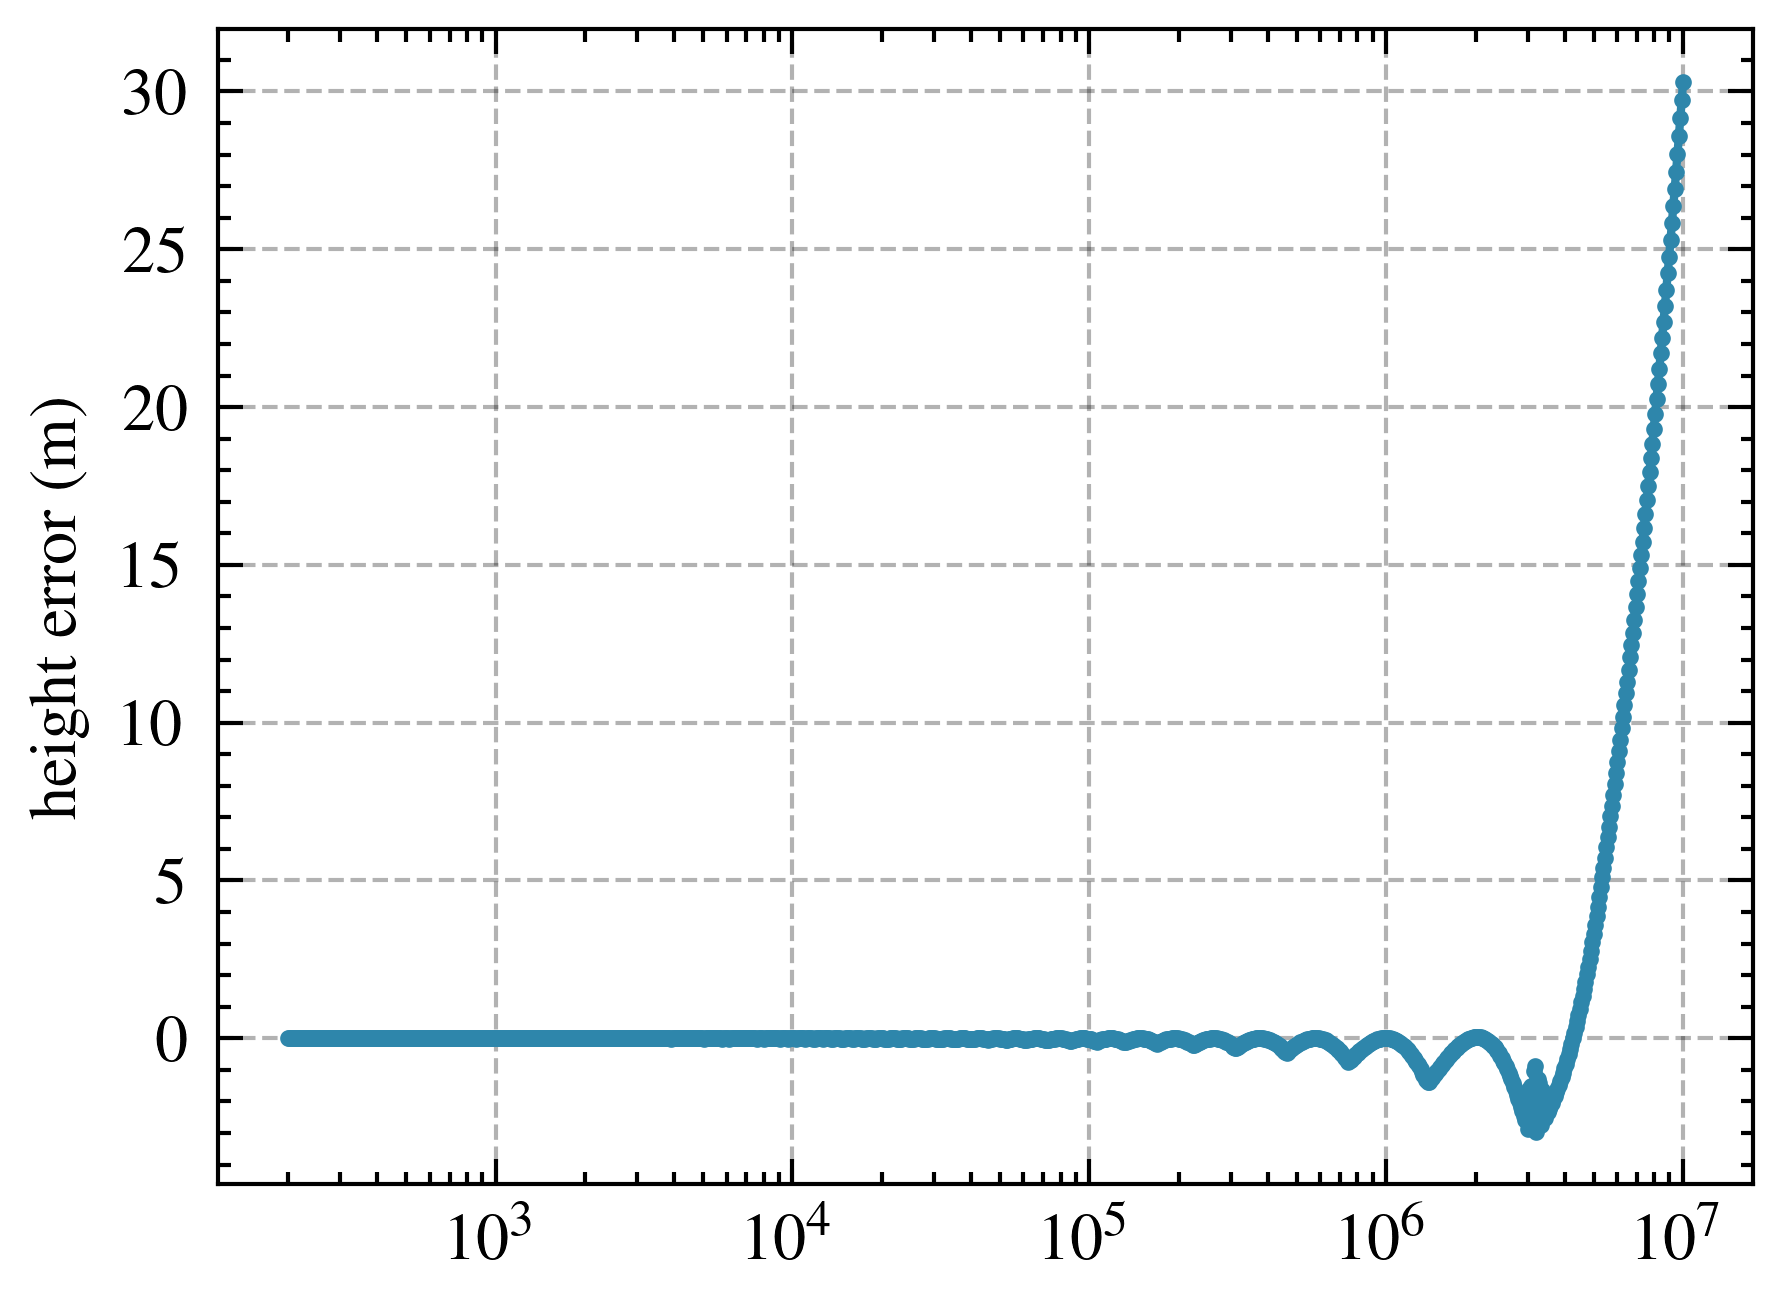

In [18]:
import matplotlib.pyplot as plt
import scienceplots
import numpy as np

# Read data from CSV using NumPy
data = np.genfromtxt('first_bouncing_data.csv', delimiter=',', skip_header=1)

# Extract x and y columns
x = data[:, 0]  # First column
y = data[:, 1]  # Second column

with plt.style.context(['science','ieee', 'grid']):
  legendStrs = []
  linestyles = ["-", ":", "--", "-."]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  plt.semilogx(x, y, marker='o', markersize=1, linewidth=1, color=scientific_colors[0])
  # plt.legend(loc="best", fontsize=8)
  # plt.legend(framealpha=0.9, loc="upper right")
  # plt.ylim(top=5.5, bottom=-0.5)
  plt.ylabel(r'height error (m)')
  plt.grid(True, linestyle='--', alpha=0.3)
  # plt.xlabel(r'Time (s)')
  # plt.title('Bouncing ball by proposed method')
  # plt.grid(True, alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

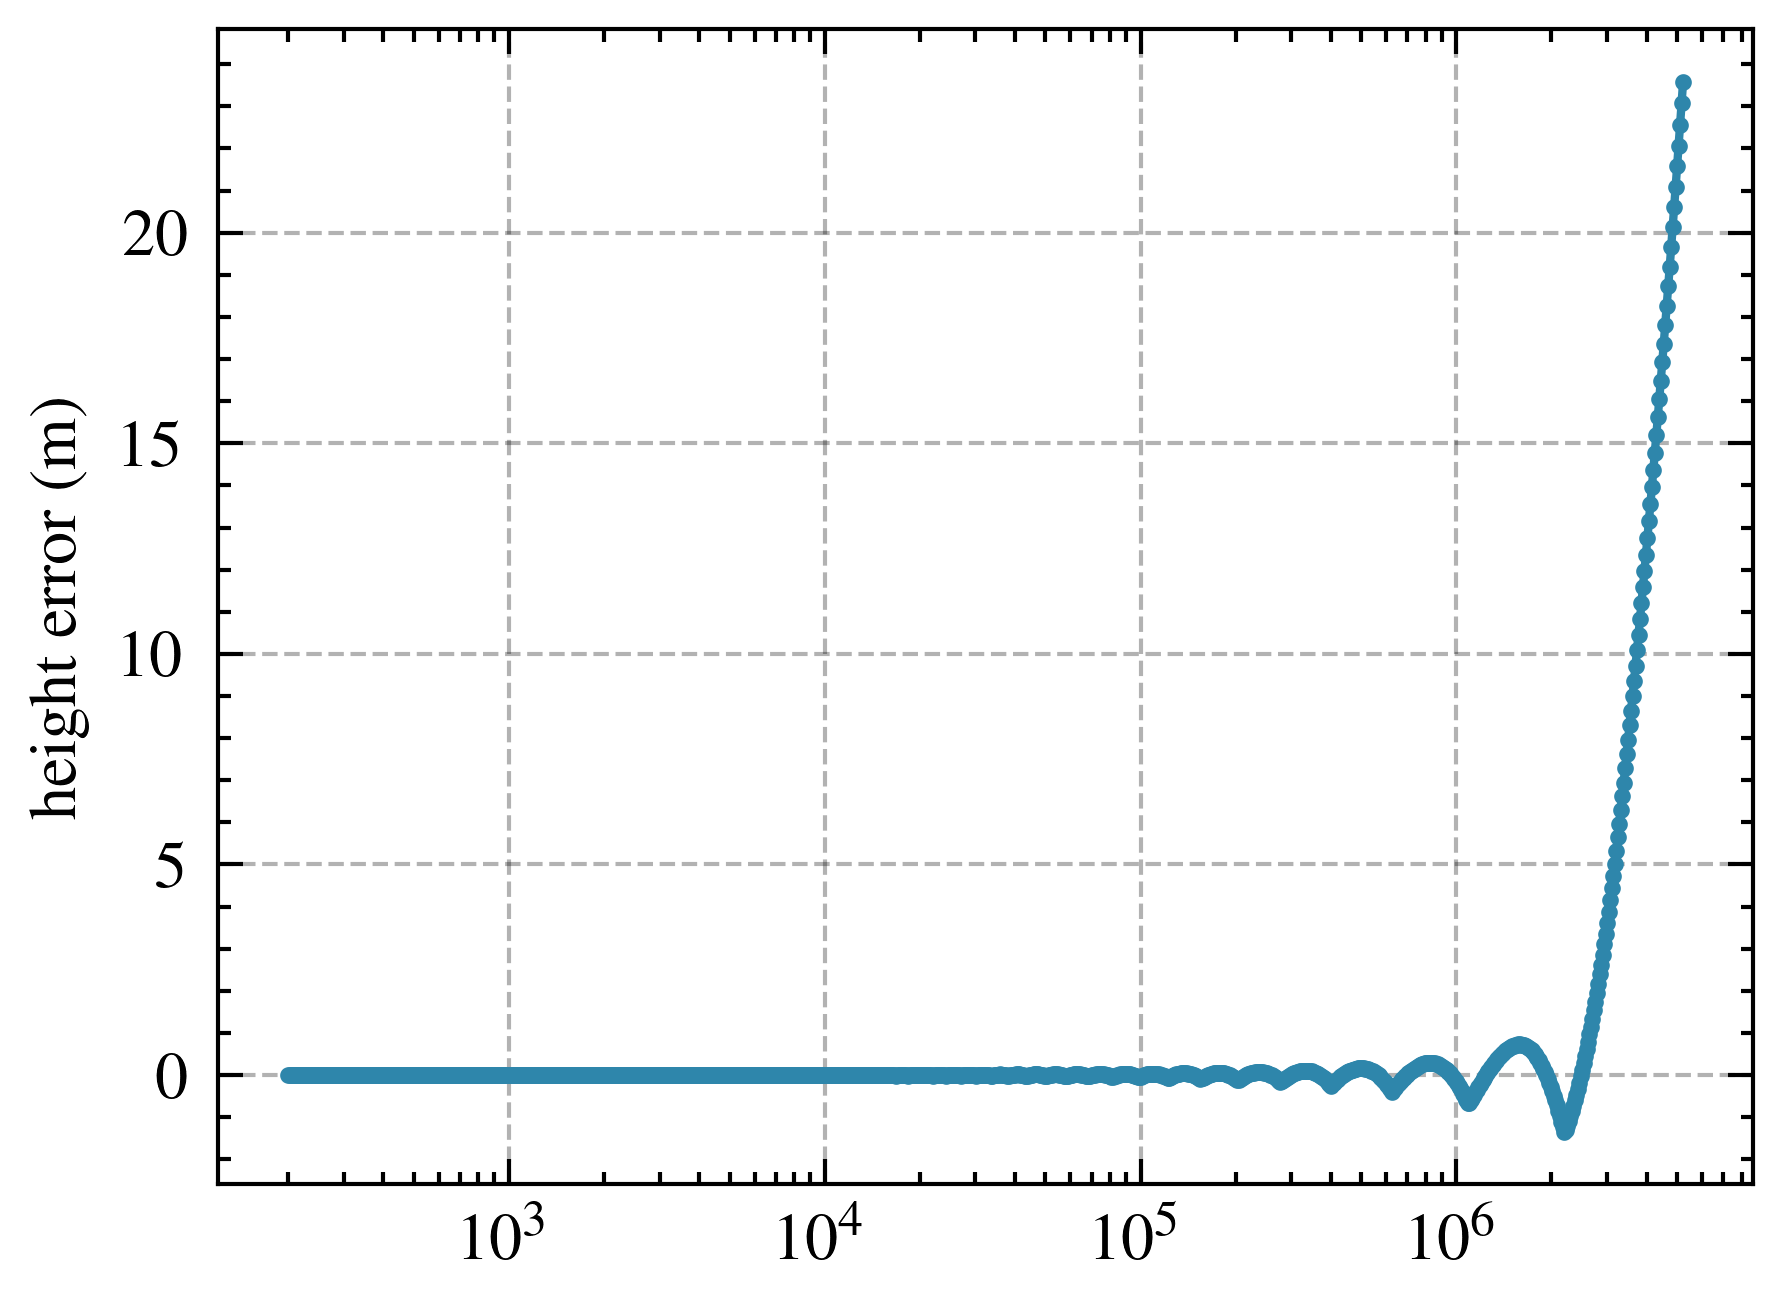

In [30]:
n = -60
with plt.style.context(['science','ieee', 'grid']):
  plt.semilogx(parameters[:n], heights[:n], marker='o', markersize=1, linewidth=1, color=scientific_colors[0])
  # plt.legend(loc="best", fontsize=8)
  # plt.legend(framealpha=0.9, loc="upper right")
  # plt.ylim(top=5.5, bottom=-0.5)
  plt.ylabel(r'height error (m)')
  plt.grid(True, linestyle='--', alpha=0.3)
  # plt.xlabel(r'Time (s)')
  # plt.title('Bouncing ball by proposed method')
  # plt.grid(True, alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

In [1]:
import mujoco
import numpy as np
from PIL import Image
import copy
from os.path import abspath
import os

def capture_frame(renderer, data, path):
    """更新渲染器并保存当前帧为图片"""
    # 同步模拟数据到渲染器
    renderer.update_scene(data)
    # 将渲染好的图像转换为像素数组
    pixels = renderer.render()
    # 使用PIL保存图像
    img = Image.fromarray(pixels)
    return img
    # img.save(path)
    # print(f"截图已保存至: {path}")

# 最简单的方法
parameters = [2e3, 2e5, 3e6, 2e8]
# parameters = [[2e2, 0], [2e30, 0]]
sim_duration = 2.2
all_results = []

heights = np.zeros(np.size(parameters))

# 运行三次不同参数的仿真
for param_idx, stiffness in enumerate(parameters):
    # print(f"运行仿真 {param_idx+1}, solref={solref}")
    
    # MuJoCo模型XML字符串，使用当前参数
    MUJOCO_MODEL_XML = f"""
<mujoco>
  <option timestep="0.001"/>
<visual>
  <global offwidth="1280" offheight="720" azimuth="-140" elevation="-20"/>
    <headlight diffuse="0.6 0.6 0.6" ambient="0.1 0.1 0.1" specular="0.9 0.9 0.9"/>
    <rgba haze="0.15 0.25 0.35 1"/>
  </visual>
  <default>
    <geom solref="-{stiffness} 0"/>
  </default>

  <asset>
    <texture type="skybox" builtin="gradient" rgb1="0.3 0.5 0.8" rgb2="0.8 0.8 0.8" width="512" height="3072"/>
    <texture type="2d" name="groundplane" builtin="checker" mark="edge" rgb1="0.2 0.3 0.4" rgb2="0.1 0.2 0.3" markrgb="0.8 0.8 0.8" width="300" height="300"/>
    <material name="groundplane" texture="groundplane" texuniform="true" texrepeat="5 5" reflectance="0.2"/>
  </asset>
  <worldbody>
      <light pos="1 0 3.5" dir="0 0 -1" directional="true"/>
    <!-- 地面 -->
    <geom name="ground" type="box" size="2.5 2.5 0.5" pos="0 0 -0.50" rgba="0.8 0.9 0.8 1"/>

      <!-- 方块 -->
      <body name="ball" pos="0 0 4.5">
        <freejoint/>
        <geom name="box_geom" type="box" size="0.5 0.5 0.5" rgba="0.9 0.2 0.2 1" mass="1"/>
      </body>
    <camera name="my_camera" mode="fixed" fovy="20" pos="30 0 0" quat="0.5 0.5 0.5 0.5"/>
  </worldbody>
  <!-- 重力设置 -->
  <option gravity="0 0 -9.81"/>
</mujoco>
"""

    # 创建模型和仿真环境
    model = mujoco.MjModel.from_xml_string(MUJOCO_MODEL_XML)
    # 2. 创建离屏渲染器
    renderer = mujoco.Renderer(model, height=720, width=1280)
    data = mujoco.MjData(model)
    # 设置仿真时长
    simulation_time = 2.2 # 仿真时间（秒）
    num_steps = int(simulation_time / model.opt.timestep)

    # 存储时间和高度数据
    # time_points = np.zeros(num_steps)
    # velocity_points = np.zeros(num_steps)

    # 运行仿真
    firstBounceHeight = 0
    # updated_max_height = False
    for i in range(num_steps):
        # 执行仿真步骤
        mujoco.mj_step(model, data)
        
        # 记录时间、高度和速度
        # time_points[i] = data.time
        height = data.qpos[2] - 0.5  # z坐标
        # velocity_points[i] = data.qvel[2]  # z方向速度
        if i > 900:
          if height > firstBounceHeight:
            firstBounceHeight = height
            data1 = copy.deepcopy(data)
            # updated_max_height = True
          # if updated_max_height:
          #    if height < firstBounceHeight:
          #       data.qpos = qpos_backup.copy()
          #       img = capture_frame(renderer, data, "")
    cam_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_CAMERA, "my_camera")
    # data.qpos = qpos_backup.copy()
    # data.qpos[2] = 1
    # img = capture_frame(renderer, data, "")
    renderer.update_scene(data1, camera=cam_id) # 在截图函数中使用
    print(firstBounceHeight, data1.qpos)
    # 将渲染好的图像转换为像素数组
    pixels = renderer.render()
    # 使用PIL保存图像
    img = Image.fromarray(pixels)
    renderer.close()
    print(img._size)
    cropped_img = img.crop((445, 0, 835, 465))
    # cropped_img = img.crop((450, 0, 820, 450))
    cropped_img.save(abspath(os.getcwd()) + f"/pic/{str(stiffness)}.png")

4.002620996481088 [3.06822274e-16 7.65129850e-17 4.50262100e+00 1.00000000e+00
 4.40594486e-16 0.00000000e+00 0.00000000e+00]
(1280, 720)
3.9769560049383053 [4.84816912e-16 3.80985904e-17 4.47695600e+00 1.00000000e+00
 3.35060498e-16 0.00000000e+00 0.00000000e+00]
(1280, 720)
3.0243034688359662 [ 7.73992603e-17 -6.10982303e-17  3.52430347e+00  1.00000000e+00
  1.01262406e-16  0.00000000e+00  0.00000000e+00]
(1280, 720)
520.670597974741 [ 1.20002164e-14  1.35098906e-15  5.21170598e+02  1.00000000e+00
 -1.39212432e-15  1.23656021e-14 -5.81484771e-31]
(1280, 720)
